# NJ Quality of Life Index — Phase 3

**Methods:** Weighted Z-Score (Method A) + PCA (Method B)
**Coverage:** ~545 NJ ZIP codes
**Sources:** ACS, Zillow, CDC PLACES, FEMA Flood, NJ Property Tax

### Domain Weights (Method A)
| Domain | Weight | Key Variables |
|---|---|---|
| Economic Security | 30% | Median income, poverty rate, unemployment |
| Housing Affordability | 20% | Price/income ratio, rent burden, tax rate |
| Education | 15% | % bachelor's+ |
| Health & Environment | 20% | Obesity, smoking, inactivity, uninsured |
| Flood & Climate Risk | 10% | % high-risk flood zone |
| Mobility | 5% | Commute time, WFH rate, transit share |

> **Note:** Safety (10%) excluded — FBI crime data not yet loaded. Redistributed to Economic Security (+5%) and Health (+5%).

In [2]:
import duckdb
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

DB_PATH = '../data/db/nj_pipeline.duckdb'
con = duckdb.connect(DB_PATH, read_only=True)
print('Connected to DuckDB')

Connected to DuckDB


## 1. Load & Merge Feature Matrix

In [3]:
# Base scorecard (ACS + Zillow + CDC + Property Tax) — 547 ZIPs
scorecard = con.execute("""
    SELECT * FROM v_zipcode_scorecard
""").df()

# Affordability metrics (home_price_to_income_ratio)
afford = con.execute("""
    SELECT zip_code, home_price_to_income_ratio, rent_to_income_pct, est_annual_ownership_cost_usd
    FROM v_affordability_index
""").df()

# FEMA flood risk
flood = con.execute("""
    SELECT zip_code, pct_high_risk_flood_zone, total_claim_count, years_with_claims
    FROM fema_flood_summary
""").df()
flood['zip_code'] = flood['zip_code'].astype(str).str.zfill(5)

print(f'Scorecard: {len(scorecard)} ZIPs')
print(f'Affordability: {len(afford)} ZIPs')
print(f'Flood: {len(flood)} ZIPs')

Scorecard: 547 ZIPs
Affordability: 545 ZIPs
Flood: 630 ZIPs


In [4]:
# Merge all sources
df = scorecard.merge(afford, on='zip_code', how='left')
df = df.merge(flood, on='zip_code', how='left')

print(f'Master matrix: {len(df)} ZIPs')
df.head(2)

Master matrix: 547 ZIPs


,zip_code,city,metro,zillow_county,home_value_zillow,rent_zillow,price_to_rent_ratio,home_value_yoy_pct,home_value_5yr_pct,pop_total,...,heart_disease_pct,property_tax_rate,avg_annual_tax_bill,avg_assessed_value_residential,home_price_to_income_ratio,rent_to_income_pct,est_annual_ownership_cost_usd,pct_high_risk_flood_zone,total_claim_count,years_with_claims
0,07001,Avenel,"New York-Newark-Jersey City, NY-NJ-PA",Middlesex County,519846.409587,NaN,NaN,1.10,39.91,17143,...,4.5,NaN,NaN,NaN,5.42,NaN,33202.0,46.285714,1.0,1.0
1,07002,Bayonne,"New York-Newark-Jersey City, NY-NJ-PA",Hudson County,572730.152783,2300.202906,20.7,-0.35,27.33,70468,...,5.4,NaN,NaN,NaN,7.05,34.0,36580.0,26.335878,5.0,4.0


## 2. Variable Selection & Missingness Audit

In [5]:
# Define QoL variables by domain
# direction: +1 = higher is better, -1 = lower is better
# NOTE: property_tax_rate excluded — 100% null in v_zipcode_scorecard (no ZIP↔municipality join yet)

DOMAINS = {
    'Economic Security': {
        'weight': 0.30,
        'vars': {
            'income_median_hh':      +1,
            'poverty_rate':          -1,
            'unemployment_rate_acs': -1,
        }
    },
    'Housing Affordability': {
        'weight': 0.20,
        'vars': {
            'home_price_to_income_ratio': -1,
            'rent_burden_30plus_pct':     -1,
        }
    },
    'Education': {
        'weight': 0.15,
        'vars': {
            'pct_bachelors_plus': +1,
        }
    },
    'Health & Environment': {
        'weight': 0.20,
        'vars': {
            'obesity_pct':               -1,
            'smoking_pct':               -1,
            'physical_inactivity_pct':   -1,
            'uninsured_pct':             -1,
        }
    },
    'Flood & Climate Risk': {
        'weight': 0.10,
        'vars': {
            'pct_high_risk_flood_zone': -1,
        }
    },
    'Mobility': {
        'weight': 0.05,
        'vars': {
            'avg_commute_minutes': -1,
            'pct_wfh':             +1,
            'pct_transit_commute': +1,
        }
    },
}

all_vars = [v for domain in DOMAINS.values() for v in domain['vars'].keys()]
print(f'Total QoL variables: {len(all_vars)}')
print()

# Missingness audit
missing = df[all_vars].isnull().mean().sort_values(ascending=False)
print('Missingness by variable:')
print(missing.apply(lambda x: f'{x:.1%}').to_string())

Total QoL variables: 14

Missingness by variable:
rent_burden_30plus_pct        1.8%
pct_high_risk_flood_zone      1.6%
avg_commute_minutes           0.7%
income_median_hh              0.4%
home_price_to_income_ratio    0.4%
poverty_rate                  0.2%
unemployment_rate_acs         0.2%
pct_bachelors_plus            0.2%
obesity_pct                   0.2%
smoking_pct                   0.2%
physical_inactivity_pct       0.2%
uninsured_pct                 0.2%
pct_wfh                       0.2%
pct_transit_commute           0.2%


In [6]:
# Fill missing flood risk with 0 (no policies = no high-risk zone classification)
df['pct_high_risk_flood_zone'] = df['pct_high_risk_flood_zone'].fillna(0)

# Impute remaining missing values with median — skip variables whose median is NaN (100% missing)
skipped = []
for v in all_vars:
    if df[v].isnull().any():
        median_val = df[v].median()
        if pd.isna(median_val):
            skipped.append(v)
            print(f'  SKIP {v}: 100% missing, cannot impute — remove from DOMAINS')
        else:
            n_missing = df[v].isnull().sum()
            df[v] = df[v].fillna(median_val)
            print(f'  Imputed {n_missing} missing in {v} with median ({median_val:.2f})')

if skipped:
    print(f'\n⚠ Variables with no data (will cause NaN scores): {skipped}')

# Filter tiny populations (< 500)
df_filtered = df[df['pop_total'] >= 500].copy().reset_index(drop=True)
print(f'\nAfter pop filter: {len(df_filtered)} ZIPs (removed {len(df) - len(df_filtered)} low-pop ZIPs)')

# Confirm no NaN in QoL variables
nan_counts = df_filtered[all_vars].isnull().sum()
nan_vars = nan_counts[nan_counts > 0]
if len(nan_vars):
    print(f'\n⚠ NaN still present after imputation:\n{nan_vars}')
else:
    print('✓ No NaN in QoL variables')

  Imputed 2 missing in income_median_hh with median (110667.00)
  Imputed 1 missing in poverty_rate with median (5.75)
  Imputed 1 missing in unemployment_rate_acs with median (5.40)
  Imputed 2 missing in home_price_to_income_ratio with median (4.86)
  Imputed 10 missing in rent_burden_30plus_pct with median (47.28)
  Imputed 1 missing in pct_bachelors_plus with median (43.80)
  Imputed 1 missing in obesity_pct with median (28.00)
  Imputed 1 missing in smoking_pct with median (10.30)
  Imputed 1 missing in physical_inactivity_pct with median (21.80)
  Imputed 1 missing in uninsured_pct with median (8.10)
  Imputed 4 missing in avg_commute_minutes with median (30.90)
  Imputed 1 missing in pct_wfh with median (14.44)
  Imputed 1 missing in pct_transit_commute with median (3.63)

After pop filter: 537 ZIPs (removed 10 low-pop ZIPs)
✓ No NaN in QoL variables


## 3. Method A — Weighted Z-Score Index

In [7]:
def compute_weighted_zscore_qol(df, domains):
    """Compute weighted Z-score QoL index and domain subscores."""
    result = df[['zip_code', 'city', 'zillow_county', 'pop_total']].copy()

    domain_scores = {}
    composite = np.zeros(len(df))

    for domain_name, domain_cfg in domains.items():
        weight = domain_cfg['weight']
        vars_dict = domain_cfg['vars']

        z_scores = []
        for col, direction in vars_dict.items():
            col_vals = df[col]
            col_std = col_vals.std()
            if col_std == 0 or pd.isna(col_std):
                raise ValueError(f"Column '{col}' has zero/NaN std — remove it from DOMAINS or check imputation")
            z = (col_vals - col_vals.mean()) / col_std
            z_scores.append(direction * z)

        domain_score = np.mean(z_scores, axis=0)
        domain_scores[domain_name] = domain_score
        composite += weight * domain_score

    # Normalize composite to 0–100
    comp_min, comp_max = composite.min(), composite.max()
    qol_score = 100 * (composite - comp_min) / (comp_max - comp_min)

    result['qol_score'] = qol_score
    result['qol_rank'] = result['qol_score'].rank(ascending=False, na_option='bottom').astype(int)

    for dname, dscore in domain_scores.items():
        key = f'score_{dname.lower().replace(" & ", "_").replace(" ", "_")}'
        d_min, d_max = dscore.min(), dscore.max()
        result[key] = 100 * (dscore - d_min) / (d_max - d_min) if d_max > d_min else 50.0

    return result.sort_values('qol_rank')

qol_a = compute_weighted_zscore_qol(df_filtered, DOMAINS)
print(f'QoL scores computed for {len(qol_a)} ZIPs')
print(f'Score range: {qol_a.qol_score.min():.1f} – {qol_a.qol_score.max():.1f}')
assert qol_a['qol_score'].isna().sum() == 0, 'NaN in qol_score!'
print('✓ No NaN in qol_score')

QoL scores computed for 537 ZIPs
Score range: 0.0 – 100.0
✓ No NaN in qol_score


In [8]:
print('=== TOP 20 ZIP CODES — Weighted Z-Score QoL ===')
cols_show = ['qol_rank', 'zip_code', 'city', 'zillow_county', 'qol_score']
print(qol_a.head(20)[cols_show].to_string(index=False))

=== TOP 20 ZIP CODES — Weighted Z-Score QoL ===
 qol_rank zip_code                  city     zillow_county  qol_score
        1    08550    Princeton Junction     Mercer County 100.000000
        2    07078           Short Hills      Essex County  99.700370
        3    07423             Ho Ho Kus     Bergen County  98.259959
        4    07046        Mountain Lakes     Morris County  97.736327
        5    07945               Mendham     Morris County  97.679319
        6    07021           Essex Fells      Essex County  97.537085
        7    07739         Little Silver   Monmouth County  96.477137
        8    08502            Belle Mead   Somerset County  95.331507
        9    07090             Westfield      Union County  94.120068
       10    07704            Fair Haven   Monmouth County  93.671418
       11    08535    Millstone Township   Monmouth County  93.245285
       12    07928               Chatham     Morris County  92.977935
       13    07649               Oradell  

In [11]:
qol_a

,zip_code,city,zillow_county,pop_total,qol_score,qol_rank,score_economic_security,score_housing_affordability,score_education,score_health_environment,score_flood_climate_risk,score_mobility
438,08550,Princeton Junction,Mercer County,20876,100.000000,1,89.152740,88.510800,93.530904,100.000000,76.572364,52.015641
65,07078,Short Hills,Essex County,14183,99.700370,2,92.535097,78.780057,100.000000,98.446989,96.243190,59.830434
116,07423,Ho Ho Kus,Bergen County,4230,98.259959,3,100.000000,89.350820,89.575646,94.136139,30.606252,52.483092
39,07046,Mountain Lakes,Morris County,4535,97.736327,4,98.388041,73.154049,93.450185,97.720224,100.000000,47.793877
280,07945,Mendham,Morris County,9771,97.679319,5,96.316424,83.365169,85.966328,94.576655,86.945676,36.847240
...,...,...,...,...,...,...,...,...,...,...,...,...
150,07522,Paterson,Passaic County,22599,9.748218,533,18.059614,63.604046,7.114852,24.645623,35.639145,38.696819
363,08104,Camden,Camden County,21508,8.244929,534,9.730591,72.766541,6.492159,21.010957,20.850112,45.275629
362,08103,Camden,Camden County,13137,8.020816,535,9.316386,76.956406,7.529982,14.790900,17.577359,43.773832
361,08102,Camden,Camden County,8090,6.631196,536,0.000000,76.159915,12.280904,18.065403,31.125148,43.238976


In [ ]:
print('=== BOTTOM 20 ZIP CODES — Weighted Z-Score QoL ===')
print(qol_a.tail(20)[cols_show].to_string(index=False))

=== BOTTOM 20 ZIP CODES — Weighted Z-Score QoL ===
 qol_rank zip_code          city    zillow_county  qol_score
      518    07107        Newark     Essex County  26.650117
      519    07106        Newark     Essex County  25.553211
      520    07104        Newark     Essex County  25.463319
      521    07723          Deal  Monmouth County  24.362615
      522    08861   Perth Amboy Middlesex County  24.110931
      523    07105        Newark     Essex County  23.312282
      524    08611       Trenton    Mercer County  23.265030
      525    08401 Atlantic City  Atlantic County  22.974795
      526    07050        Orange     Essex County  22.469946
      527    07055       Passaic   Passaic County  19.938979
      528    07502      Paterson   Passaic County  19.594405
      529    08105        Camden    Camden County  18.850546
      530    07524      Paterson   Passaic County  15.473334
      531    07501      Paterson   Passaic County  11.988461
      532    07108        Newark  

## 4. Method B — PCA Index

In [ ]:
# Direction-adjusted feature matrix
X = df_filtered[all_vars].copy()
for domain_cfg in DOMAINS.values():
    for col, direction in domain_cfg['vars'].items():
        if direction == -1:
            X[col] = -X[col]  # flip so higher = better

# Handle any remaining NaN before PCA
all_nan_cols = X.columns[X.isna().all()]
if len(all_nan_cols):
    print(f'Filling all-NaN columns with 0 for PCA: {list(all_nan_cols)}')
    X[all_nan_cols] = 0

if X.isna().any().any():
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='median')
    X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit PCA
pca = PCA()
pca.fit(X_scaled)

# Explained variance
cumvar = np.cumsum(pca.explained_variance_ratio_)
n_components_70 = np.argmax(cumvar >= 0.70) + 1
n_components_80 = np.argmax(cumvar >= 0.80) + 1
print(f'Components to explain 70% variance: {n_components_70}')
print(f'Components to explain 80% variance: {n_components_80}')
print(f'PC1 explains: {pca.explained_variance_ratio_[0]:.1%}')
print(f'PC2 explains: {pca.explained_variance_ratio_[1]:.1%}')


Components to explain 70% variance: 4
Components to explain 80% variance: 5
PC1 explains: 49.2%
PC2 explains: 12.2%


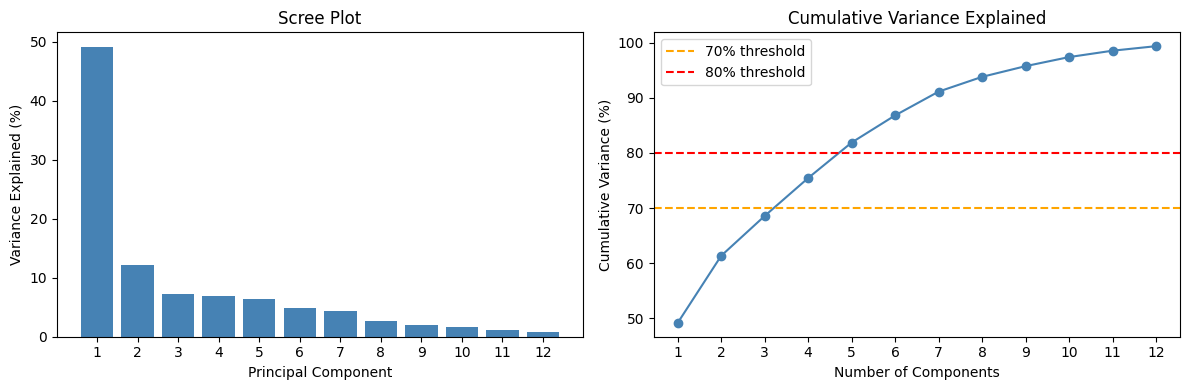

In [ ]:
# Scree plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

n_show = min(12, len(all_vars))
ax1.bar(range(1, n_show+1), pca.explained_variance_ratio_[:n_show] * 100, color='steelblue')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Variance Explained (%)')
ax1.set_title('Scree Plot')
ax1.set_xticks(range(1, n_show+1))

ax2.plot(range(1, n_show+1), cumvar[:n_show] * 100, 'o-', color='steelblue')
ax2.axhline(70, ls='--', color='orange', label='70% threshold')
ax2.axhline(80, ls='--', color='red', label='80% threshold')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Variance (%)')
ax2.set_title('Cumulative Variance Explained')
ax2.legend()
ax2.set_xticks(range(1, n_show+1))

plt.tight_layout()
plt.savefig('../NJ_Analysis_Vault/EDA Findings/qol_pca_scree.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# PC1 loadings — confirm it's an economic prosperity axis
loadings = pd.Series(pca.components_[0], index=all_vars).sort_values()
print('=== PC1 Loadings (most negative → most positive) ===')
print(loadings.to_string())

=== PC1 Loadings (most negative → most positive) ===
avg_commute_minutes          -0.171777
pct_transit_commute          -0.007274
home_price_to_income_ratio    0.039896
pct_high_risk_flood_zone      0.071522
rent_burden_30plus_pct        0.112366
unemployment_rate_acs         0.221938
pct_wfh                       0.308695
poverty_rate                  0.321466
uninsured_pct                 0.326027
obesity_pct                   0.330898
income_median_hh              0.332614
pct_bachelors_plus            0.349119
smoking_pct                   0.352036
physical_inactivity_pct       0.361918


In [ ]:
# PCA score: use PC1 as primary index (highest explained variance)
scores_pca = pca.transform(X_scaled)
pc1_scores = scores_pca[:, 0]

# Normalize to 0–100
pc1_min, pc1_max = pc1_scores.min(), pc1_scores.max()
qol_pca_norm = 100 * (pc1_scores - pc1_min) / (pc1_max - pc1_min)

qol_b = df_filtered[['zip_code', 'city', 'zillow_county', 'pop_total']].copy()
qol_b['qol_pca_score'] = qol_pca_norm
qol_b['qol_pca_rank'] = qol_b['qol_pca_score'].rank(ascending=False).astype(int)
qol_b = qol_b.sort_values('qol_pca_rank')

print('=== TOP 20 ZIP CODES — PCA QoL ===')
print(qol_b.head(20)[['qol_pca_rank','zip_code','city','zillow_county','qol_pca_score']].to_string(index=False))

=== TOP 20 ZIP CODES — PCA QoL ===
 qol_pca_rank zip_code               city   zillow_county  qol_pca_score
            1    08550 Princeton Junction   Mercer County     100.000000
            2    07078        Short Hills    Essex County      99.809211
            3    07043          Montclair    Essex County      96.610129
            4    07046     Mountain Lakes   Morris County      95.429980
            5    07423          Ho Ho Kus   Bergen County      94.757732
            6    07021        Essex Fells    Essex County      93.938308
            7    07945            Mendham   Morris County      93.673140
            8    07928            Chatham   Morris County      91.631435
            9    08502         Belle Mead Somerset County      91.449051
           10    07028         Glen Ridge    Essex County      91.180103
           11    07090          Westfield    Union County      90.702383
           12    07649            Oradell   Bergen County      90.605044
           13   

In [ ]:
print('=== BOTTOM 20 ZIP CODES — PCA QoL ===')
print(qol_b.tail(20)[['qol_pca_rank','zip_code','city','zillow_county','qol_pca_score']].to_string(index=False))

=== BOTTOM 20 ZIP CODES — PCA QoL ===
 qol_pca_rank zip_code          city     zillow_county  qol_pca_score
          518    07502      Paterson    Passaic County      25.403677
          519    08609       Trenton     Mercer County      24.951709
          520    07107        Newark      Essex County      24.434382
          521    07206     Elizabeth      Union County      24.006409
          522    07503      Paterson    Passaic County      23.878563
          523    08302     Bridgeton Cumberland County      22.000908
          524    08861   Perth Amboy  Middlesex County      21.972822
          525    08232 Pleasantville   Atlantic County      21.211490
          526    08611       Trenton     Mercer County      20.493719
          527    07055       Passaic    Passaic County      20.231736
          528    08401 Atlantic City   Atlantic County      16.661569
          529    07524      Paterson    Passaic County      16.626994
          530    07108        Newark      Essex Coun

## 5. Compare Methods & Validate

Spearman rank correlation between methods: ρ = 0.956 (p=1.61e-287)


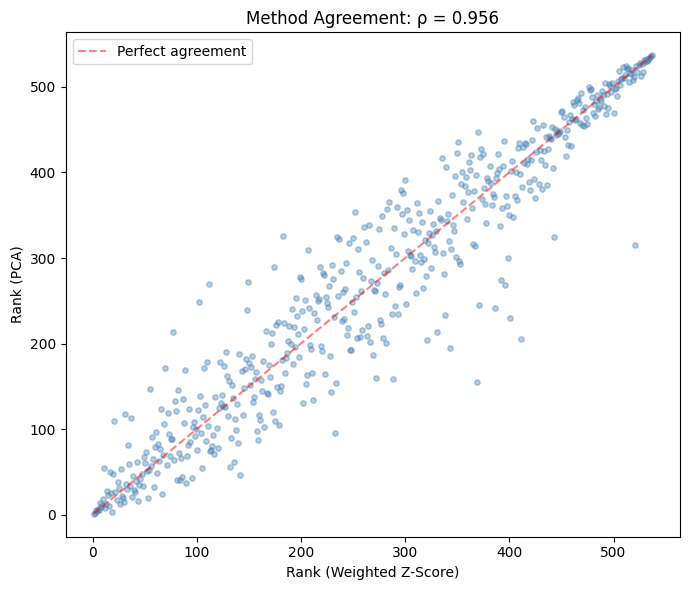

In [ ]:
# Merge both rankings
combined = qol_a[['zip_code', 'city', 'zillow_county', 'qol_score', 'qol_rank']].merge(
    qol_b[['zip_code', 'qol_pca_score', 'qol_pca_rank']], on='zip_code'
)

# Rank correlation
from scipy.stats import spearmanr
rho, pval = spearmanr(combined['qol_rank'], combined['qol_pca_rank'])
print(f'Spearman rank correlation between methods: ρ = {rho:.3f} (p={pval:.2e})')

# Scatter: rank agreement
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(combined['qol_rank'], combined['qol_pca_rank'], alpha=0.4, s=15, color='steelblue')
ax.set_xlabel('Rank (Weighted Z-Score)')
ax.set_ylabel('Rank (PCA)')
ax.set_title(f'Method Agreement: ρ = {rho:.3f}')
# Add 45° line
lim = max(combined['qol_rank'].max(), combined['qol_pca_rank'].max())
ax.plot([1, lim], [1, lim], 'r--', alpha=0.5, label='Perfect agreement')
ax.legend()
plt.tight_layout()
plt.savefig('../NJ_Analysis_Vault/EDA Findings/qol_rank_agreement.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Rank disagreement: biggest divergences
combined['rank_diff'] = (combined['qol_rank'] - combined['qol_pca_rank']).abs()
print('=== TOP 15 BIGGEST RANK DISAGREEMENTS ===')
cols_diff = ['zip_code', 'city', 'zillow_county', 'qol_rank', 'qol_pca_rank', 'rank_diff']
print(combined.nlargest(15, 'rank_diff')[cols_diff].to_string(index=False))

=== TOP 15 BIGGEST RANK DISAGREEMENTS ===
zip_code                 city     zillow_county  qol_rank  qol_pca_rank  rank_diff
   08008  Long Beach Township      Ocean County       369           155        214
   08735           Lavallette      Ocean County       411           205        206
   07723                 Deal   Monmouth County       521           315        206
   07421         West Milford    Passaic County       401           230        171
   08343          Monroeville Gloucester County       112           270        158
   08403             Longport   Atlantic County       343           195        148
   08041 Springfield Township Burlington County       102           249        147
   08243        Sea Isle City   Cape May County       386           241        145
   08097     Woodbury Heights Gloucester County       183           326        143
   08230           Ocean View   Cape May County        77           214        137
   08202               Avalon   Cape May Coun

In [ ]:
# Validation: expected known high/low scorers
known_high = ['Princeton', 'Rumson', 'Westfield', 'Summit', 'Montclair', 'Ridgewood']
known_low  = ['Camden', 'Trenton', 'Paterson', 'Atlantic City', 'Newark']

print('=== VALIDATION — Expected High Scorers ===')
for city in known_high:
    rows = combined[combined['city'].str.contains(city, case=False, na=False)]
    if len(rows):
        for _, r in rows.iterrows():
            total = len(combined)
            print(f'  {r.city:20s} ({r.zip_code})  ZScore rank: {r.qol_rank:3d}/{total}  PCA rank: {r.qol_pca_rank:3d}/{total}')
    else:
        print(f'  {city}: not found in Zillow city data')

print()
print('=== VALIDATION — Expected Low Scorers ===')
for city in known_low:
    rows = combined[combined['city'].str.contains(city, case=False, na=False)]
    if len(rows):
        for _, r in rows.iterrows():
            total = len(combined)
            print(f'  {r.city:20s} ({r.zip_code})  ZScore rank: {r.qol_rank:3d}/{total}  PCA rank: {r.qol_pca_rank:3d}/{total}')
    else:
        print(f'  {city}: not found in Zillow city data')

=== VALIDATION — Expected High Scorers ===
  Princeton Junction   (08550)  ZScore rank:   1/537  PCA rank:   1/537
  Princeton            (08540)  ZScore rank:  36/537  PCA rank:  33/537
  Princeton            (08542)  ZScore rank: 101/537  PCA rank: 122/537
  Rumson               (07760)  ZScore rank:  95/537  PCA rank:  43/537
  Westfield            (07090)  ZScore rank:   9/537  PCA rank:  11/537
  Summit               (07901)  ZScore rank:  64/537  PCA rank:  63/537
  Montclair            (07043)  ZScore rank:  19/537  PCA rank:   3/537
  Montclair            (07042)  ZScore rank: 202/537  PCA rank: 131/537
  Ridgewood            (07450)  ZScore rank:  38/537  PCA rank:  21/537

=== VALIDATION — Expected Low Scorers ===
  Camden               (08105)  ZScore rank: 529/537  PCA rank: 531/537
  Camden               (08104)  ZScore rank: 534/537  PCA rank: 534/537
  Camden               (08103)  ZScore rank: 535/537  PCA rank: 535/537
  Camden               (08102)  ZScore rank: 536/5

## 6. Sensitivity Analysis (±10% Weight Perturbation)

In [ ]:
def perturb_weights(domains, perturbation=0.10):
    """Return domains with randomly perturbed weights (renormalized)."""
    import copy
    perturbed = copy.deepcopy(domains)
    for d in perturbed.values():
        d['weight'] *= (1 + np.random.uniform(-perturbation, perturbation))
    total = sum(d['weight'] for d in perturbed.values())
    for d in perturbed.values():
        d['weight'] /= total
    return perturbed

np.random.seed(42)
n_trials = 100
rank_matrix = np.zeros((len(df_filtered), n_trials))

for i in range(n_trials):
    perturbed = perturb_weights(DOMAINS, 0.10)
    trial = compute_weighted_zscore_qol(df_filtered, perturbed)
    rank_matrix[:, i] = trial.set_index('zip_code').loc[df_filtered['zip_code']]['qol_rank'].values

# Rank stability: std dev of rank across trials
rank_std = pd.Series(rank_matrix.std(axis=1), index=df_filtered['zip_code'].values)
print(f'Median rank std dev across {n_trials} trials: {rank_std.median():.1f}')
print(f'90th pct rank std dev: {rank_std.quantile(0.90):.1f}')
print()
print('Most unstable ZIP codes (rank swings most):')
unstable = rank_std.nlargest(10).reset_index()
unstable.columns = ['zip_code', 'rank_std']
unstable = unstable.merge(df_filtered[['zip_code','city']], on='zip_code')
print(unstable[['zip_code','city','rank_std']].to_string(index=False))

Median rank std dev across 100 trials: 2.6
90th pct rank std dev: 5.5

Most unstable ZIP codes (rank swings most):
zip_code                 city  rank_std
   07852            Ledgewood 13.127266
   08247         Stone Harbor 11.648498
   08008  Long Beach Township 11.166898
   07711           Allenhurst 10.907222
   08720            Allenwood 10.731612
   08202               Avalon 10.731314
   08317              Dorothy 10.221795
   08750             Sea Girt  9.931083
   08041 Springfield Township  9.658178
   07935        Green Village  9.454544


## 7. Domain Subscores Deep-Dive

In [ ]:
# Full output with all domain subscores
qol_full = qol_a.merge(df_filtered[all_vars + ['zip_code', 'income_median_hh', 'poverty_rate',
                                                  'home_value_zillow', 'pop_total']],
                        on='zip_code', suffixes=('', '_raw'))

subscore_cols = [c for c in qol_a.columns if c.startswith('score_')]
print('Domain subscores available:')
for c in subscore_cols:
    print(f'  {c}: {qol_a[c].min():.1f} – {qol_a[c].max():.1f}')

Domain subscores available:
  score_economic_security: 0.0 – 100.0
  score_housing_affordability: 0.0 – 100.0
  score_education: 0.0 – 100.0
  score_health_environment: 0.0 – 100.0
  score_flood_climate_risk: 0.0 – 100.0
  score_mobility: 0.0 – 100.0


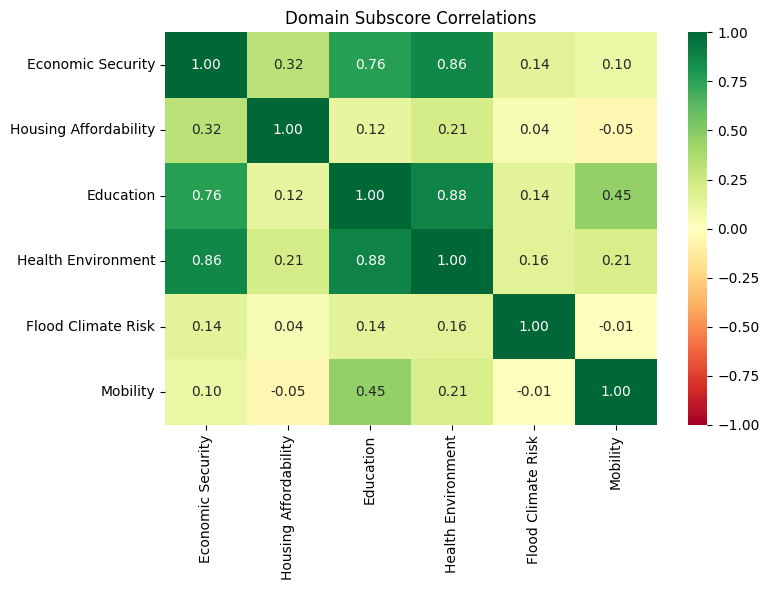

In [ ]:
# Correlation between domain subscores
fig, ax = plt.subplots(figsize=(8, 6))
corr_matrix = qol_a[subscore_cols].corr()
labels = [c.replace('score_', '').replace('_', ' ').title() for c in subscore_cols]
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            xticklabels=labels, yticklabels=labels, ax=ax,
            vmin=-1, vmax=1, center=0)
ax.set_title('Domain Subscore Correlations')
plt.tight_layout()
plt.savefig('../NJ_Analysis_Vault/EDA Findings/qol_domain_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

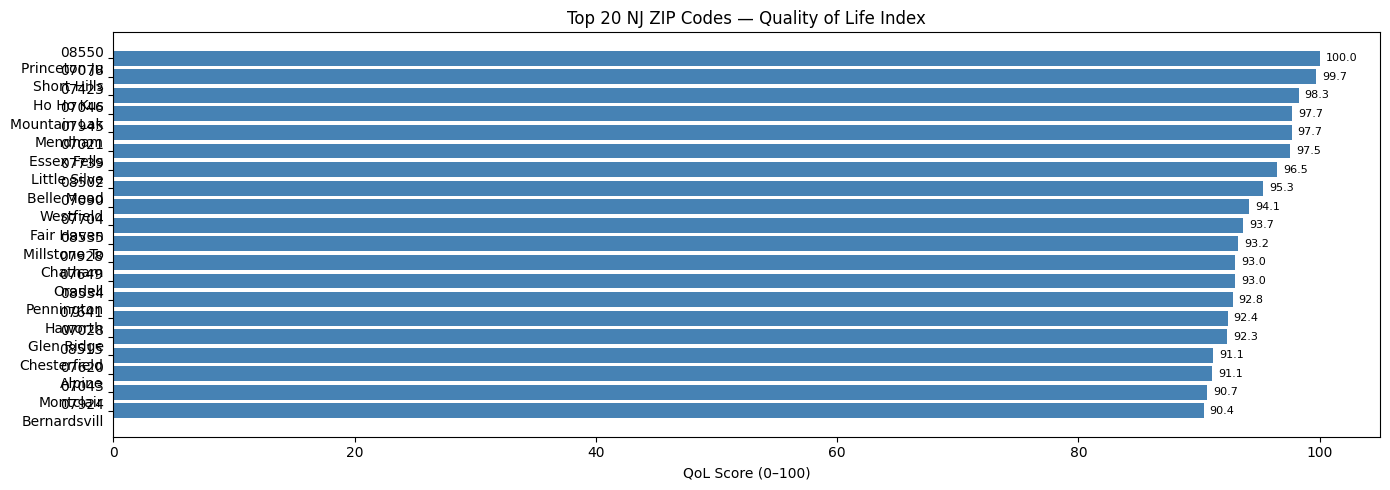

In [ ]:
# Top 20 bar chart — Z-score method
top20 = qol_a.head(20).copy()
top20['label'] = top20['zip_code'] + '\n' + top20['city'].str[:12]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.barh(top20['label'][::-1], top20['qol_score'][::-1], color='steelblue')
ax.set_xlabel('QoL Score (0–100)')
ax.set_title('Top 20 NJ ZIP Codes — Quality of Life Index')
ax.set_xlim(0, 105)
for bar, score in zip(bars, top20['qol_score'][::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{score:.1f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('../NJ_Analysis_Vault/EDA Findings/qol_top20.png', dpi=150, bbox_inches='tight')
plt.show()

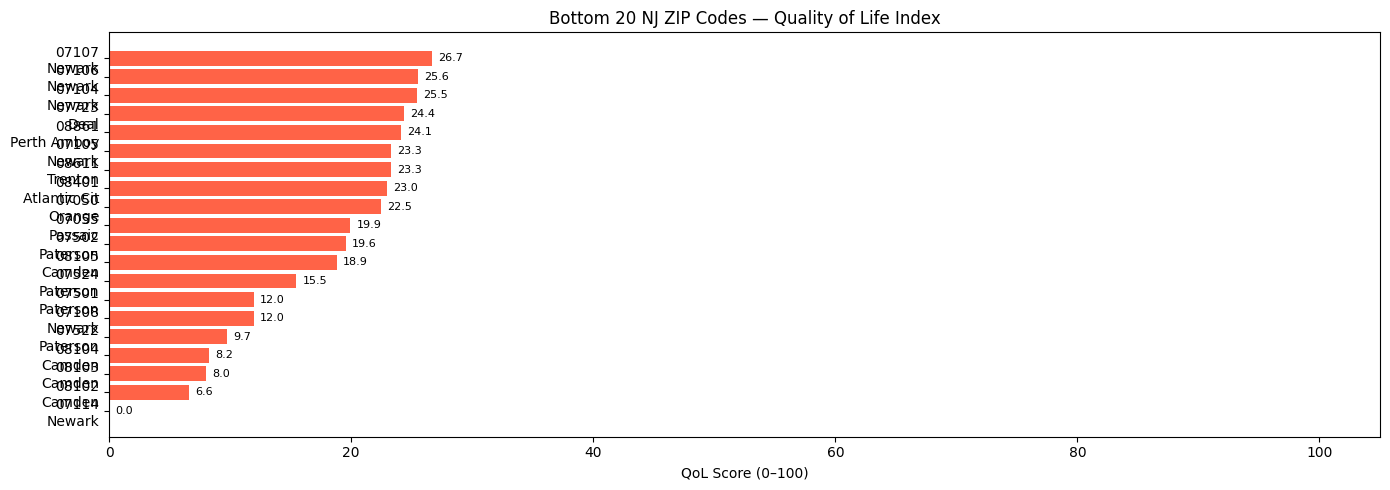

In [ ]:
# Bottom 20 bar chart
bot20 = qol_a.tail(20).copy()
bot20['label'] = bot20['zip_code'] + '\n' + bot20['city'].str[:12]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.barh(bot20['label'][::-1], bot20['qol_score'][::-1], color='tomato')
ax.set_xlabel('QoL Score (0–100)')
ax.set_title('Bottom 20 NJ ZIP Codes — Quality of Life Index')
ax.set_xlim(0, 105)
for bar, score in zip(bars, bot20['qol_score'][::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{score:.1f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('../NJ_Analysis_Vault/EDA Findings/qol_bottom20.png', dpi=150, bbox_inches='tight')
plt.show()

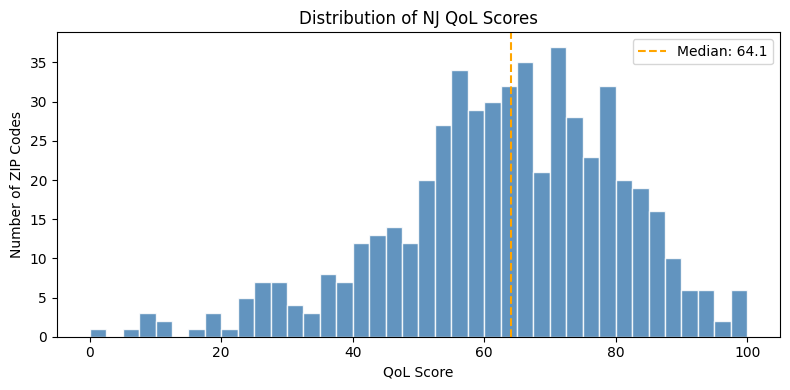

In [ ]:
# QoL score distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(qol_a['qol_score'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(qol_a['qol_score'].median(), color='orange', ls='--', label=f'Median: {qol_a.qol_score.median():.1f}')
ax.set_xlabel('QoL Score')
ax.set_ylabel('Number of ZIP Codes')
ax.set_title('Distribution of NJ QoL Scores')
ax.legend()
plt.tight_layout()
plt.savefig('../NJ_Analysis_Vault/EDA Findings/qol_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. County-Level Summary

In [ ]:
county_summary = qol_a.groupby('zillow_county').agg(
    n_zips=('zip_code', 'count'),
    avg_qol=('qol_score', 'mean'),
    median_qol=('qol_score', 'median'),
    min_qol=('qol_score', 'min'),
    max_qol=('qol_score', 'max'),
).round(1).sort_values('median_qol', ascending=False)

print('=== QoL by County (sorted by median QoL) ===')
print(county_summary.to_string())

=== QoL by County (sorted by median QoL) ===
                   n_zips  avg_qol  median_qol  min_qol  max_qol
zillow_county                                                   
Somerset County        21     75.6        78.4     42.0     95.3
Morris County          45     75.6        76.3     40.5     97.7
Hunterdon County       19     72.9        74.1     59.6     85.6
Bergen County          65     69.2        72.7     33.3     98.3
Mercer County          19     64.8        70.9     23.3    100.0
Monmouth County        49     67.9        68.6     24.4     96.5
Middlesex County       35     64.1        66.4     24.1     89.0
Gloucester County      23     62.7        63.6     38.9     87.5
Sussex County          17     65.5        62.5     54.5     89.7
Burlington County      26     63.4        61.9     46.8     91.1
Warren County           9     61.3        59.9     47.5     80.4
Essex County           31     55.6        57.5      0.0     99.7
Cape May County        12     58.5        56.

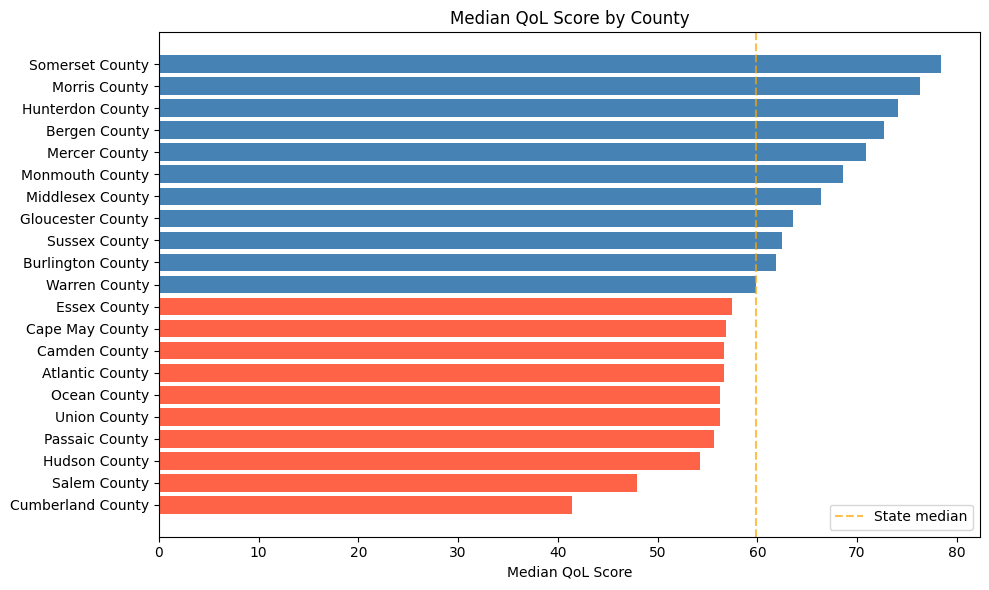

In [ ]:
# County chart
fig, ax = plt.subplots(figsize=(10, 6))
counties = county_summary.sort_values('median_qol')
colors = ['steelblue' if v >= county_summary['median_qol'].median() else 'tomato'
          for v in counties['median_qol']]
ax.barh(counties.index, counties['median_qol'], color=colors)
ax.set_xlabel('Median QoL Score')
ax.set_title('Median QoL Score by County')
ax.axvline(county_summary['median_qol'].median(), ls='--', color='orange', alpha=0.7, label='State median')
ax.legend()
plt.tight_layout()
plt.savefig('../NJ_Analysis_Vault/EDA Findings/qol_by_county.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Save Results

In [ ]:
import os

# Build final output table
output = qol_a.copy()
output = output.merge(qol_b[['zip_code', 'qol_pca_score', 'qol_pca_rank']], on='zip_code')

# Add key raw variables for context
raw_cols = ['zip_code', 'income_median_hh', 'poverty_rate', 'unemployment_rate_acs',
            'pct_bachelors_plus', 'homeownership_rate', 'home_price_to_income_ratio',
            'rent_burden_30plus_pct', 'obesity_pct', 'smoking_pct',
            'physical_inactivity_pct', 'uninsured_pct', 'pct_high_risk_flood_zone',
            'avg_commute_minutes', 'pct_wfh', 'pct_transit_commute']
output = output.merge(df_filtered[raw_cols], on='zip_code')

# Save parquet
os.makedirs('../data/processed', exist_ok=True)
output.to_parquet('../data/processed/qol_scores.parquet', index=False)
print(f'Saved qol_scores.parquet ({len(output)} rows, {len(output.columns)} cols)')
print(output.columns.tolist())

ImportError: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - `Import pyarrow` failed. pyarrow is required for parquet support. Use pip or conda to install the pyarrow package.
 - `Import fastparquet` failed. fastparquet is required for parquet support. Use pip or conda to install the fastparquet package.

In [ ]:
# Load into DuckDB as qol_scores table
con_rw = duckdb.connect('../data/db/nj_pipeline.duckdb')
con_rw.execute('DROP TABLE IF EXISTS qol_scores')
con_rw.execute("CREATE TABLE qol_scores AS SELECT * FROM read_parquet('../data/processed/qol_scores.parquet')")
count = con_rw.execute('SELECT COUNT(*) FROM qol_scores').fetchone()[0]
con_rw.close()
print(f'Created qol_scores table in DuckDB ({count} rows)')

ConnectionException: Connection Error: Can't open a connection to same database file with a different configuration than existing connections

## 10. Summary Stats

In [ ]:
print('=== QoL INDEX SUMMARY ===')
print(f'ZIP codes analyzed: {len(output)}')
print(f'Score range: {output.qol_score.min():.1f} – {output.qol_score.max():.1f}')
print(f'Mean: {output.qol_score.mean():.1f}  Median: {output.qol_score.median():.1f}')
print()
print('Tier breakdown:')
print(f'  Elite (80–100): {(output.qol_score >= 80).sum()} ZIPs')
print(f'  High  (60–80):  {((output.qol_score >= 60) & (output.qol_score < 80)).sum()} ZIPs')
print(f'  Mid   (40–60):  {((output.qol_score >= 40) & (output.qol_score < 60)).sum()} ZIPs')
print(f'  Low   (20–40):  {((output.qol_score >= 20) & (output.qol_score < 40)).sum()} ZIPs')
print(f'  Distressed (0–20): {(output.qol_score < 20).sum()} ZIPs')
print()
print(f'Method correlation: ρ = {rho:.3f}')
print(f'Sensitivity (median rank std): {rank_std.median():.1f} positions')

=== QoL INDEX SUMMARY ===
ZIP codes analyzed: 537
Score range: 0.0 – 100.0
Mean: 63.0  Median: 64.1

Tier breakdown:
  Elite (80–100): 85 ZIPs
  High  (60–80):  238 ZIPs
  Mid   (40–60):  161 ZIPs
  Low   (20–40):  42 ZIPs
  Distressed (0–20): 11 ZIPs

Method correlation: ρ = 0.956
Sensitivity (median rank std): 2.6 positions


In [ ]:
# elite zip codes (top 20%)
elite_zips = output[output['qol_score'] >= 80].sort_values('qol_score', ascending=False)
print()
print(f'Elite ZIP codes ({len(elite_zips)}):')
print(elite_zips[['zip_code', 'city', 'qol_score']].head(100).to_string(index=False))


Elite ZIP codes (85):
zip_code                   city  qol_score
   08550     Princeton Junction 100.000000
   07078            Short Hills  99.700370
   07423              Ho Ho Kus  98.259959
   07046         Mountain Lakes  97.736327
   07945                Mendham  97.679319
   07021            Essex Fells  97.537085
   07739          Little Silver  96.477137
   08502             Belle Mead  95.331507
   07090              Westfield  94.120068
   07704             Fair Haven  93.671418
   08535     Millstone Township  93.245285
   07928                Chatham  92.977935
   07649                Oradell  92.971916
   08534             Pennington  92.779467
   07641                Haworth  92.360260
   07028             Glen Ridge  92.294142
   08515  Chesterfield Township  91.136773
   07620                 Alpine  91.101203
   07043              Montclair  90.685093
   07924          Bernardsville  90.369353
   07418               Glenwood  89.706461
   07922       Berkeley Heights

In [ ]:
con.close()
print('Done. Outputs saved:')
print('  ../data/processed/qol_scores.parquet')
print('  DuckDB: qol_scores table')
print('  ../NJ_Analysis_Vault/EDA Findings/qol_*.png')